In [1]:
# ================================================
# ML Basics — understanding the concepts
# before applying them to World Cup data
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

print("All libraries imported successfully")
print()
print("Machine Learning in one sentence:")
print("A model finds patterns in past data and uses them to predict future outcomes.")
print()
print("In our project:")
print("  Past data  = 32,000 international football matches")
print("  Pattern    = which team/form/h2h factors predict the result")
print("  Prediction = Home Win / Away Win / Draw for a new match")

All libraries imported successfully

Machine Learning in one sentence:
A model finds patterns in past data and uses them to predict future outcomes.

In our project:
  Past data  = 32,000 international football matches
  Pattern    = which team/form/h2h factors predict the result
  Prediction = Home Win / Away Win / Draw for a new match


In [2]:
# Features = inputs to the model
# Labels   = what we want to predict

df = pd.read_csv("../data/processed/features.csv")

feature_cols = [
    "home_team_enc", "away_team_enc",
    "home_form", "away_form", "form_diff",
    "home_h2h_rate", "is_neutral"
]

X = df[feature_cols]   # features — what the model sees
y = df["result"]       # label — what the model predicts

print("Features (X) — inputs:")
print(X.head())
print()
print("Label (y) — what we predict:")
print(y.head())
print()
print(f"X shape: {X.shape}  →  {X.shape[0]} matches, {X.shape[1]} features")
print(f"y unique values: {y.unique()}")

Features (X) — inputs:
   home_team_enc  away_team_enc  home_form  away_form  form_diff  \
0              4            172        0.5        0.5        0.0   
1              4             46        1.0        0.5        0.5   
2            114             28        0.5        0.5        0.0   
3            183             13        0.5        0.5        0.0   
4            169            285        0.5        0.5        0.0   

   home_h2h_rate  is_neutral  
0            0.5           1  
1            0.5           1  
2            0.5           0  
3            0.5           1  
4            0.5           1  

Label (y) — what we predict:
0    Home Win
1    Home Win
2    Home Win
3    Home Win
4        Draw
Name: result, dtype: str

X shape: (32314, 7)  →  32314 matches, 7 features
y unique values: <ArrowStringArray>
['Home Win', 'Draw', 'Away Win']
Length: 3, dtype: str


In [3]:
# Why split data into train and test?
# If you test on data you trained on, results look perfect but fail in real world
# Always hold back 20% of data to test on — data the model has never seen

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42,    # same split every time
    stratify=y          # keeps class ratios equal in both sets
)

print(f"Training set: {len(X_train)} matches  ({len(X_train)/len(X):.0%} of data)")
print(f"Testing set:  {len(X_test)} matches  ({len(X_test)/len(X):.0%} of data)")
print()
print("Training distribution:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Testing distribution:")
print(y_test.value_counts(normalize=True).round(3))
print()
print("Both sets have similar class distributions — stratify=y worked correctly")

Training set: 25851 matches  (80% of data)
Testing set:  6463 matches  (20% of data)

Training distribution:
result
Home Win    0.485
Away Win    0.280
Draw        0.235
Name: proportion, dtype: float64

Testing distribution:
result
Home Win    0.485
Away Win    0.280
Draw        0.235
Name: proportion, dtype: float64

Both sets have similar class distributions — stratify=y worked correctly


In [4]:
# Train a Random Forest Classifier
# A Random Forest builds 100+ decision trees and takes a majority vote

model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    max_depth=8,        # how deep each tree can grow
    random_state=42
)

model.fit(X_train, y_train)
print("Model trained successfully!")
print()

# Make predictions on test set
y_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Training accuracy: {train_acc:.2%}")
print(f"Testing accuracy:  {test_acc:.2%}")
print()
print("If training acc >> testing acc, the model is overfitting")
print("A gap of <10% is acceptable")

Model trained successfully!

Training accuracy: 56.48%
Testing accuracy:  54.11%

If training acc >> testing acc, the model is overfitting
A gap of <10% is acceptable


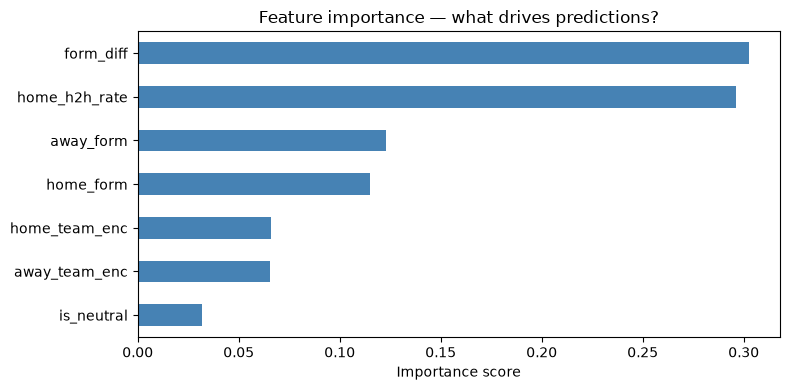


Higher = more important to the model's decisions
form features usually rank highest — recent form is the strongest predictor


In [5]:
# Which features matter most to the model?
importances = pd.Series(
    model.feature_importances_, index=feature_cols
).sort_values()

importances.plot(kind="barh", figsize=(8, 4), color="steelblue")
plt.title("Feature importance — what drives predictions?")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

print()
print("Higher = more important to the model's decisions")
print("form features usually rank highest — recent form is the strongest predictor")